In [109]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2

warnings.filterwarnings("ignore")

print("Imports successful")

Imports successful


In [110]:
PROJECT_ROOT = Path(
    r"C:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk"
)

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"
RISK_PATH = PROJECT_ROOT / "data" / "risk"

SRC_PATH = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project:", PROJECT_ROOT)
print("Processed:", PROCESSED_PATH)
print("Risk:", RISK_PATH)

Project: C:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk
Processed: C:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk\data\processed
Risk: C:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk\data\risk


In [111]:
required_files = {
    "Portfolio Returns": PROCESSED_PATH / "portfolio_returns.csv",
    "Historical VaR": RISK_PATH / "rolling_var.csv",
    "EWMA VaR": RISK_PATH / "ewma_var.csv",
    "GARCH VaR": PROCESSED_PATH / "garch_var.csv",
    "GJR-GARCH VaR": PROCESSED_PATH / "gjr_garch_var.csv",
}

for name, path in required_files.items():

    print(
        f"{name:20} : "
        f"{'FOUND' if path.exists() else 'MISSING'}"
    )

Portfolio Returns    : FOUND
Historical VaR       : FOUND
EWMA VaR             : FOUND
GARCH VaR            : FOUND
GJR-GARCH VaR        : FOUND


In [112]:
portfolio_df = pd.read_csv(
    PROCESSED_PATH / "portfolio_returns.csv"
)

print("Shape:", portfolio_df.shape)
print("Columns:", portfolio_df.columns.tolist())

display(portfolio_df.head())

Shape: (1652, 2)
Columns: ['Date', '0']


,Date,0
0,2020-01-03,-0.006352
1,2020-01-06,0.010729
2,2020-01-07,0.000712
3,2020-01-08,0.010445
4,2020-01-09,0.005718


In [113]:
possible_return_columns = [
    "Portfolio Return",
    "Portfolio_Return",
    "portfolio_return",
    "PortfolioReturn",
    "Return",
    "return",
    "Returns",
    "returns",
    "0"
]

return_column = None

for column in possible_return_columns:

    if column in portfolio_df.columns:
        return_column = column
        break

if return_column is None:

    raise ValueError(
        "Portfolio return column not found.\n"
        f"Available columns: {portfolio_df.columns.tolist()}"
    )

print("Portfolio return column:", return_column)

Portfolio return column: 0


In [114]:
portfolio_df["Date"] = pd.to_datetime(
    portfolio_df["Date"],
    errors="coerce"
)

portfolio_df[return_column] = pd.to_numeric(
    portfolio_df[return_column],
    errors="coerce"
)

portfolio_df = (
    portfolio_df
    .dropna(subset=["Date", return_column])
    .sort_values("Date")
    .reset_index(drop=True)
)

portfolio_df["Actual Return"] = portfolio_df[
    return_column
]

portfolio_df["Actual Loss"] = -portfolio_df[
    "Actual Return"
]

print("Observations:", len(portfolio_df))
print("Start:", portfolio_df["Date"].min())
print("End:", portfolio_df["Date"].max())

display(
    portfolio_df[
        ["Date", "Actual Return", "Actual Loss"]
    ].head()
)

Observations: 1652
Start: 2020-01-03 00:00:00
End: 2026-07-31 00:00:00


,Date,Actual Return,Actual Loss
0,2020-01-03,-0.006352,0.006352
1,2020-01-06,0.010729,-0.010729
2,2020-01-07,0.000712,-0.000712
3,2020-01-08,0.010445,-0.010445
4,2020-01-09,0.005718,-0.005718


In [115]:
ESTIMATION_WINDOW = 750

CONFIDENCE_LEVEL = 0.99

ALPHA = 1 - CONFIDENCE_LEVEL

EWMA_LAMBDA = 0.94

print("Estimation window:", ESTIMATION_WINDOW)
print("Confidence level:", CONFIDENCE_LEVEL)
print("Alpha:", ALPHA)
print("EWMA lambda:", EWMA_LAMBDA)

print(
    "Potential OOS observations:",
    len(portfolio_df) - ESTIMATION_WINDOW
)

Estimation window: 750
Confidence level: 0.99
Alpha: 0.010000000000000009
EWMA lambda: 0.94
Potential OOS observations: 902


In [116]:
historical_var_df = pd.read_csv(
    RISK_PATH / "rolling_var.csv"
)

print(
    "Historical VaR shape:",
    historical_var_df.shape
)

print(
    "Historical VaR columns:",
    historical_var_df.columns.tolist()
)

display(historical_var_df.head())

Historical VaR shape: (1652, 10)
Historical VaR columns: ['Date', 'VaR_95_250D', 'VaR_99_250D', 'VaR_99_5_250D', 'VaR_95_500D', 'VaR_99_500D', 'VaR_99_5_500D', 'VaR_95_750D', 'VaR_99_750D', 'VaR_99_5_750D']


,Date,VaR_95_250D,VaR_99_250D,VaR_99_5_250D,VaR_95_500D,VaR_99_500D,VaR_99_5_500D,VaR_95_750D,VaR_99_750D,VaR_99_5_750D
0,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [117]:
ewma_var_df = pd.read_csv(
    RISK_PATH / "ewma_var.csv"
)

print(
    "EWMA VaR shape:",
    ewma_var_df.shape
)

print(
    "EWMA VaR columns:",
    ewma_var_df.columns.tolist()
)

display(ewma_var_df.head())

EWMA VaR shape: (1652, 2)
EWMA VaR columns: ['Date', 'EWMA VaR']


,Date,EWMA VaR
0,2020-01-03,NaN
1,2020-01-06,NaN
2,2020-01-07,NaN
3,2020-01-08,NaN
4,2020-01-09,NaN


In [118]:
garch_var_df = pd.read_csv(
    PROCESSED_PATH / "garch_var.csv"
)

print(
    "GARCH VaR shape:",
    garch_var_df.shape
)

print(
    "GARCH VaR columns:",
    garch_var_df.columns.tolist()
)

display(garch_var_df)

GARCH VaR shape: (3, 4)
GARCH VaR columns: ['Confidence', 'Historical VaR', 'GARCH Scaled VaR', '1-Day Forecast Volatility']


,Confidence,Historical VaR,GARCH Scaled VaR,1-Day Forecast Volatility
0,0.90,0.017991,0.018302,0.01473
1,0.95,0.026534,0.024194,0.01473
2,0.99,0.049400,0.040045,0.01473


In [119]:
gjr_garch_var_df = pd.read_csv(
    PROCESSED_PATH / "gjr_garch_var.csv"
)

print(
    "GJR-GARCH VaR shape:",
    gjr_garch_var_df.shape
)

print(
    "GJR-GARCH VaR columns:",
    gjr_garch_var_df.columns.tolist()
)

display(gjr_garch_var_df)

GJR-GARCH VaR shape: (3, 8)
GJR-GARCH VaR columns: ['Confidence', 'VaR', 'Omega', 'Alpha', 'Gamma', 'Beta', 'Persistence', 'Forecast Volatility']


,Confidence,VaR,Omega,Alpha,Gamma,Beta,Persistence,Forecast Volatility
0,0.90,0.016756,0.066954,0.008334,0.131835,0.894907,0.969158,0.013755
1,0.95,0.022642,0.066954,0.008334,0.131835,0.894907,0.969158,0.013755
2,0.99,0.037686,0.066954,0.008334,0.131835,0.894907,0.969158,0.013755


In [120]:
print("=" * 80)
print("PORTFOLIO RETURNS")
print("=" * 80)

print(portfolio_df.columns.tolist())

print("\n" + "=" * 80)
print("HISTORICAL VAR")
print("=" * 80)

print(historical_var_df.columns.tolist())

print("\n" + "=" * 80)
print("EWMA VAR")
print("=" * 80)

print(ewma_var_df.columns.tolist())

print("\n" + "=" * 80)
print("GARCH VAR")
print("=" * 80)

print(garch_var_df.columns.tolist())

print("\n" + "=" * 80)
print("GJR-GARCH VAR")
print("=" * 80)

print(gjr_garch_var_df.columns.tolist())

PORTFOLIO RETURNS
['Date', '0', 'Actual Return', 'Actual Loss']

HISTORICAL VAR
['Date', 'VaR_95_250D', 'VaR_99_250D', 'VaR_99_5_250D', 'VaR_95_500D', 'VaR_99_500D', 'VaR_99_5_500D', 'VaR_95_750D', 'VaR_99_750D', 'VaR_99_5_750D']

EWMA VAR
['Date', 'EWMA VaR']

GARCH VAR
['Confidence', 'Historical VaR', 'GARCH Scaled VaR', '1-Day Forecast Volatility']

GJR-GARCH VAR
['Confidence', 'VaR', 'Omega', 'Alpha', 'Gamma', 'Beta', 'Persistence', 'Forecast Volatility']


In [121]:
def find_date_column(df):

    candidates = [
        "Date",
        "date",
        "DATE",
        "Datetime",
        "datetime"
    ]

    for column in candidates:

        if column in df.columns:
            return column

    return None

In [122]:
def find_var_column(df, preferred_keywords=None):

    if preferred_keywords is None:

        preferred_keywords = [
            "VaR",
            "var",
            "Value at Risk"
        ]

    # Exact/common names first
    exact_candidates = [
        "VaR",
        "Historical VaR",
        "Rolling VaR",
        "EWMA VaR",
        "GARCH VaR",
        "GARCH Scaled VaR",
        "GJR-GARCH VaR",
        "GJR-GARCH Scaled VaR"
    ]

    for column in exact_candidates:

        if column in df.columns:
            return column

    # Keyword search
    for column in df.columns:

        column_string = str(column).lower()

        if any(
            keyword.lower() in column_string
            for keyword in preferred_keywords
        ):

            if "confidence" not in column_string:

                return column

    return None

In [123]:
hist_date_col = find_date_column(
    historical_var_df
)

hist_var_col = find_var_column(
    historical_var_df
)

print("Date column:", hist_date_col)
print("VaR column:", hist_var_col)

Date column: Date
VaR column: VaR_95_250D


In [124]:
if hist_date_col is None:

    raise ValueError(
        "No Date column found in rolling_var.csv"
    )

if hist_var_col is None:

    raise ValueError(
        "No VaR column found in rolling_var.csv"
    )


historical_var_clean = historical_var_df[
    [hist_date_col, hist_var_col]
].copy()

historical_var_clean.columns = [
    "Date",
    "Historical VaR"
]

historical_var_clean["Date"] = pd.to_datetime(
    historical_var_clean["Date"],
    errors="coerce"
)

historical_var_clean["Historical VaR"] = pd.to_numeric(
    historical_var_clean["Historical VaR"],
    errors="coerce"
)

historical_var_clean = (
    historical_var_clean
    .dropna()
    .sort_values("Date")
    .reset_index(drop=True)
)

display(
    historical_var_clean.head()
)

,Date,Historical VaR
0,2020-12-29,0.04029
1,2020-12-30,0.04029
2,2020-12-31,0.04029
3,2021-01-04,0.04029
4,2021-01-05,0.04029


In [125]:
ewma_date_col = find_date_column(
    ewma_var_df
)

ewma_var_col = find_var_column(
    ewma_var_df
)

print("Date column:", ewma_date_col)
print("VaR column:", ewma_var_col)

Date column: Date
VaR column: EWMA VaR


In [126]:
if ewma_date_col is None:

    raise ValueError(
        "No Date column found in ewma_var.csv"
    )

if ewma_var_col is None:

    raise ValueError(
        "No VaR column found in ewma_var.csv"
    )


ewma_var_clean = ewma_var_df[
    [ewma_date_col, ewma_var_col]
].copy()

ewma_var_clean.columns = [
    "Date",
    "EWMA VaR"
]

ewma_var_clean["Date"] = pd.to_datetime(
    ewma_var_clean["Date"],
    errors="coerce"
)

ewma_var_clean["EWMA VaR"] = pd.to_numeric(
    ewma_var_clean["EWMA VaR"],
    errors="coerce"
)

ewma_var_clean = (
    ewma_var_clean
    .dropna()
    .sort_values("Date")
    .reset_index(drop=True)
)

display(
    ewma_var_clean.head()
)

,Date,EWMA VaR
0,2020-12-30,0.019954
1,2020-12-31,0.019363
2,2021-01-04,0.018776
3,2021-01-05,0.018884
4,2021-01-06,0.018928


In [127]:
backtest_df = portfolio_df[
    [
        "Date",
        "Actual Return",
        "Actual Loss"
    ]
].copy()

backtest_df = backtest_df.merge(
    historical_var_clean,
    on="Date",
    how="inner"
)

backtest_df = backtest_df.merge(
    ewma_var_clean,
    on="Date",
    how="inner"
)

backtest_df = (
    backtest_df
    .sort_values("Date")
    .reset_index(drop=True)
)

print(
    "Backtest observations:",
    len(backtest_df)
)

display(
    backtest_df.head()
)

Backtest observations: 1402


,Date,Actual Return,Actual Loss,Historical VaR,EWMA VaR
0,2020-12-30,0.000099,-0.000099,0.04029,0.019954
1,2020-12-31,0.003025,-0.003025,0.04029,0.019363
2,2021-01-04,-0.006719,0.006719,0.04029,0.018776
3,2021-01-05,0.010697,-0.010697,0.04029,0.018884
4,2021-01-06,-0.004489,0.004489,0.04029,0.018928


In [128]:
print(
    backtest_df[
        [
            "Actual Loss",
            "Historical VaR",
            "EWMA VaR"
        ]
    ].describe()
)

       Actual Loss  Historical VaR     EWMA VaR
count  1402.000000     1402.000000  1402.000000
mean     -0.000736        0.024853     0.024361
std       0.014410        0.006678     0.011328
min      -0.112955        0.015013     0.009741
25%      -0.008730        0.019341     0.016533
50%      -0.001254        0.024391     0.019855
75%       0.006357        0.028060     0.029601
max       0.060859        0.040290     0.080182


In [129]:
display(
    backtest_df.head()
)

,Date,Actual Return,Actual Loss,Historical VaR,EWMA VaR
0,2020-12-30,0.000099,-0.000099,0.04029,0.019954
1,2020-12-31,0.003025,-0.003025,0.04029,0.019363
2,2021-01-04,-0.006719,0.006719,0.04029,0.018776
3,2021-01-05,0.010697,-0.010697,0.04029,0.018884
4,2021-01-06,-0.004489,0.004489,0.04029,0.018928


In [130]:
portfolio_start_date = portfolio_df.loc[
    ESTIMATION_WINDOW,
    "Date"
]

print(
    "OOS start date:",
    portfolio_start_date
)

backtest_df = backtest_df[
    backtest_df["Date"] >= portfolio_start_date
].copy()

backtest_df = (
    backtest_df
    .sort_values("Date")
    .reset_index(drop=True)
)

print(
    "OOS observations:",
    len(backtest_df)
)

OOS start date: 2022-12-23 00:00:00
OOS observations: 902


In [131]:
backtest_df["Historical Exception"] = (
    backtest_df["Actual Loss"]
    > backtest_df["Historical VaR"]
).astype(int)

backtest_df["EWMA Exception"] = (
    backtest_df["Actual Loss"]
    > backtest_df["EWMA VaR"]
).astype(int)

display(
    backtest_df.head(10)
)

,Date,Actual Return,Actual Loss,Historical VaR,EWMA VaR,Historical Exception,EWMA Exception
0,2022-12-23,0.005357,-0.005357,0.037331,0.037602,0,0
1,2022-12-27,-0.025499,0.025499,0.037331,0.036490,0,0
2,2022-12-28,-0.007419,0.007419,0.037331,0.037052,0,0
3,2022-12-29,0.028412,-0.028412,0.037331,0.036260,0,0
4,2022-12-30,0.002258,-0.002258,0.037331,0.037253,0,0
5,2023-01-03,-0.017240,0.017240,0.037331,0.036122,0,0
6,2023-01-04,0.003110,-0.003110,0.037331,0.035595,0,0
7,2023-01-05,-0.015989,0.015989,0.037331,0.033748,0,0
8,2023-01-06,0.021615,-0.021615,0.037331,0.033636,0,0
9,2023-01-09,0.011733,-0.011733,0.037331,0.034296,0,0


In [132]:
garch_vol_df = pd.read_csv(
    PROCESSED_PATH / "garch_volatility.csv"
)

print(
    "GARCH volatility shape:",
    garch_vol_df.shape
)

print(
    "Columns:",
    garch_vol_df.columns.tolist()
)

display(
    garch_vol_df.head()
)

GARCH volatility shape: (1652, 4)
Columns: ['Date', 'Portfolio Return', 'Conditional Volatility', 'Standardized Residual']


,Date,Portfolio Return,Conditional Volatility,Standardized Residual
0,2020-01-03,-0.009045,0.020835,-0.494645
1,2020-01-06,0.009246,0.019837,0.402521
2,2020-01-07,-0.000913,0.018811,-0.115564
3,2020-01-08,0.009735,0.017695,0.478924
4,2020-01-09,0.009290,0.016892,0.475313


In [133]:
gjr_vol_df = pd.read_csv(
    PROCESSED_PATH / "gjr_garch_volatility.csv"
)

print(
    "GJR-GARCH volatility shape:",
    gjr_vol_df.shape
)

print(
    "Columns:",
    gjr_vol_df.columns.tolist()
)

display(
    gjr_vol_df.head()
)

GJR-GARCH volatility shape: (1652, 3)
Columns: ['Date', 'GJR-GARCH Conditional Volatility', 'Standardized Residual']


,Date,GJR-GARCH Conditional Volatility,Standardized Residual
0,2020-01-03,0.020781,-0.475292
1,2020-01-06,0.020171,0.417127
2,2020-01-07,0.019271,-0.090554
3,2020-01-08,0.018425,0.483211
4,2020-01-09,0.017640,0.479466


In [134]:
garch_scaled_df = pd.read_csv(
    PROCESSED_PATH / "garch_scaled_returns.csv"
)

print(
    "GARCH scaled returns:",
    garch_scaled_df.shape
)

print(
    garch_scaled_df.columns.tolist()
)

display(
    garch_scaled_df.head()
)

GARCH scaled returns: (1652, 5)
['Date', 'Portfolio Return', 'Conditional Volatility', 'Scaling Factor', 'GARCH Scaled Return']


,Date,Portfolio Return,Conditional Volatility,Scaling Factor,GARCH Scaled Return
0,2020-01-03,-0.009045,0.020835,0.706972,-0.006395
1,2020-01-06,0.009246,0.019837,0.742526,0.006865
2,2020-01-07,-0.000913,0.018811,0.783060,-0.000715
3,2020-01-08,0.009735,0.017695,0.832451,0.008104
4,2020-01-09,0.009290,0.016892,0.872017,0.008101


In [135]:
gjr_scaled_df = pd.read_csv(
    PROCESSED_PATH / "gjr_garch_scaled_returns.csv"
)

print(
    "GJR-GARCH scaled returns:",
    gjr_scaled_df.shape
)

print(
    gjr_scaled_df.columns.tolist()
)

display(
    gjr_scaled_df.head()
)

GJR-GARCH scaled returns: (1652, 2)
['Date', 'GJR-GARCH Scaled Return']


,Date,GJR-GARCH Scaled Return
0,2020-01-03,-0.005987
1,2020-01-06,0.006305
2,2020-01-07,-0.000652
3,2020-01-08,0.007268
4,2020-01-09,0.007244


In [136]:
def kupiec_pof_test(
    exceptions,
    confidence_level=0.99
):

    exceptions = np.asarray(
        exceptions,
        dtype=int
    )

    n = len(exceptions)
    x = int(exceptions.sum())

    if n == 0:
        return {
            "LR POF": np.nan,
            "p-value": np.nan,
            "Pass": False
        }

    p = 1 - confidence_level

    phat = x / n

    eps = 1e-12

    p_safe = np.clip(
        p,
        eps,
        1 - eps
    )

    phat_safe = np.clip(
        phat,
        eps,
        1 - eps
    )

    log_l_null = (
        x * np.log(p_safe)
        + (n - x) * np.log(1 - p_safe)
    )

    log_l_alt = (
        x * np.log(phat_safe)
        + (n - x) * np.log(1 - phat_safe)
    )

    lr = -2 * (
        log_l_null - log_l_alt
    )

    p_value = chi2.sf(
        lr,
        df=1
    )

    return {
        "LR POF": lr,
        "p-value": p_value,
        "Pass": p_value >= 0.05
    }

In [137]:
def christoffersen_independence_test(
    exceptions
):

    exceptions = np.asarray(
        exceptions,
        dtype=int
    )

    if len(exceptions) < 2:

        return {
            "LR Independence": np.nan,
            "p-value": np.nan,
            "Pass": False
        }

    n00 = 0
    n01 = 0
    n10 = 0
    n11 = 0

    for i in range(1, len(exceptions)):

        previous = exceptions[i - 1]
        current = exceptions[i]

        if previous == 0 and current == 0:
            n00 += 1

        elif previous == 0 and current == 1:
            n01 += 1

        elif previous == 1 and current == 0:
            n10 += 1

        elif previous == 1 and current == 1:
            n11 += 1

    total = (
        n00 + n01 + n10 + n11
    )

    if total == 0:
        return {
            "LR Independence": np.nan,
            "p-value": np.nan,
            "Pass": False
        }

    n0 = n00 + n01
    n1 = n10 + n11

    pi01 = (
        n01 / n0
        if n0 > 0
        else 0
    )

    pi11 = (
        n11 / n1
        if n1 > 0
        else 0
    )

    pi = (
        (n01 + n11) / total
    )

    eps = 1e-12

    pi = np.clip(
        pi,
        eps,
        1 - eps
    )

    pi01 = np.clip(
        pi01,
        eps,
        1 - eps
    )

    pi11 = np.clip(
        pi11,
        eps,
        1 - eps
    )

    log_l_independent = (
        (n00 + n10) * np.log(1 - pi)
        + (n01 + n11) * np.log(pi)
    )

    log_l_markov = (
        n00 * np.log(1 - pi01)
        + n01 * np.log(pi01)
        + n10 * np.log(1 - pi11)
        + n11 * np.log(pi11)
    )

    lr = -2 * (
        log_l_independent
        - log_l_markov
    )

    p_value = chi2.sf(
        lr,
        df=1
    )

    return {
        "LR Independence": lr,
        "p-value": p_value,
        "Pass": p_value >= 0.05
    }

In [138]:
def christoffersen_conditional_coverage_test(
    exceptions,
    confidence_level=0.99
):

    kupiec = kupiec_pof_test(
        exceptions,
        confidence_level
    )

    independence = (
        christoffersen_independence_test(
            exceptions
        )
    )

    lr_cc = (
        kupiec["LR POF"]
        + independence["LR Independence"]
    )

    p_value = chi2.sf(
        lr_cc,
        df=2
    )

    return {
        "LR Conditional Coverage": lr_cc,
        "p-value": p_value,
        "Pass": p_value >= 0.05
    }

In [139]:
def basel_traffic_light(
    exceptions
):

    exceptions = np.asarray(
        exceptions,
        dtype=int
    )

    n = len(exceptions)
    x = int(exceptions.sum())

    if n != 250:

        return {
            "Zone": "N/A",
            "Exceptions": x
        }

    if x <= 4:

        zone = "Green"

    elif x <= 9:

        zone = "Yellow"

    else:

        zone = "Red"

    return {
        "Zone": zone,
        "Exceptions": x
    }

In [140]:
def run_model_backtest(
    df,
    var_column,
    confidence_level=0.99
):

    data = df[
        [
            "Actual Loss",
            var_column
        ]
    ].dropna()

    exceptions = (
        data["Actual Loss"]
        > data[var_column]
    ).astype(int).values

    n = len(exceptions)

    x = int(
        exceptions.sum()
    )

    expected_exceptions = (
        n * (1 - confidence_level)
    )

    exception_ratio = (
        x / n
        if n > 0
        else np.nan
    )

    kupiec = kupiec_pof_test(
        exceptions,
        confidence_level
    )

    independence = (
        christoffersen_independence_test(
            exceptions
        )
    )

    conditional = (
        christoffersen_conditional_coverage_test(
            exceptions,
            confidence_level
        )
    )

    basel = basel_traffic_light(
        exceptions
    )

    return {
        "Model": var_column.replace(
            " VaR",
            ""
        ),

        "Observations": n,

        "Exceptions": x,

        "Expected Exceptions":
            expected_exceptions,

        "Exception Ratio":
            exception_ratio,

        "LR POF":
            kupiec["LR POF"],

        "Kupiec p-value":
            kupiec["p-value"],

        "Kupiec Pass":
            kupiec["Pass"],

        "LR Independence":
            independence[
                "LR Independence"
            ],

        "Independence p-value":
            independence[
                "p-value"
            ],

        "Independence Pass":
            independence[
                "Pass"
            ],

        "LR Conditional Coverage":
            conditional[
                "LR Conditional Coverage"
            ],

        "Conditional Coverage p-value":
            conditional[
                "p-value"
            ],

        "Conditional Coverage Pass":
            conditional[
                "Pass"
            ],

        "Basel Zone":
            basel["Zone"]
    }

In [141]:
models_to_test = [
    "Historical VaR",
    "EWMA VaR"
]

results = []

for model in models_to_test:

    result = run_model_backtest(
        backtest_df,
        model,
        CONFIDENCE_LEVEL
    )

    results.append(result)

results_df = pd.DataFrame(
    results
)

display(results_df)

,Model,Observations,Exceptions,Expected Exceptions,Exception Ratio,LR POF,Kupiec p-value,Kupiec Pass,LR Independence,Independence p-value,Independence Pass,LR Conditional Coverage,Conditional Coverage p-value,Conditional Coverage Pass,Basel Zone
0,Historical,902,31,9.02,0.034368,33.127173,8.632388e-09,False,5.312712,0.021170,False,38.439885,4.496609e-09,False,N/A
1,EWMA,902,44,9.02,0.048780,70.886081,3.784586e-17,False,1.439262,0.230259,True,72.325343,1.971293e-16,False,N/A


In [142]:
results_display = results_df.copy()

results_display["Exception Ratio"] = (
    results_display["Exception Ratio"] * 100
).round(2)

results_display["Expected Exceptions"] = (
    results_display[
        "Expected Exceptions"
    ].round(2)
)

p_value_columns = [
    "Kupiec p-value",
    "Independence p-value",
    "Conditional Coverage p-value"
]

for column in p_value_columns:

    results_display[column] = (
        results_display[column]
        .round(4)
    )

display(results_display)

,Model,Observations,Exceptions,Expected Exceptions,Exception Ratio,LR POF,Kupiec p-value,Kupiec Pass,LR Independence,Independence p-value,Independence Pass,LR Conditional Coverage,Conditional Coverage p-value,Conditional Coverage Pass,Basel Zone
0,Historical,902,31,9.02,3.44,33.127173,0.0,False,5.312712,0.0212,False,38.439885,0.0,False,N/A
1,EWMA,902,44,9.02,4.88,70.886081,0.0,False,1.439262,0.2303,True,72.325343,0.0,False,N/A


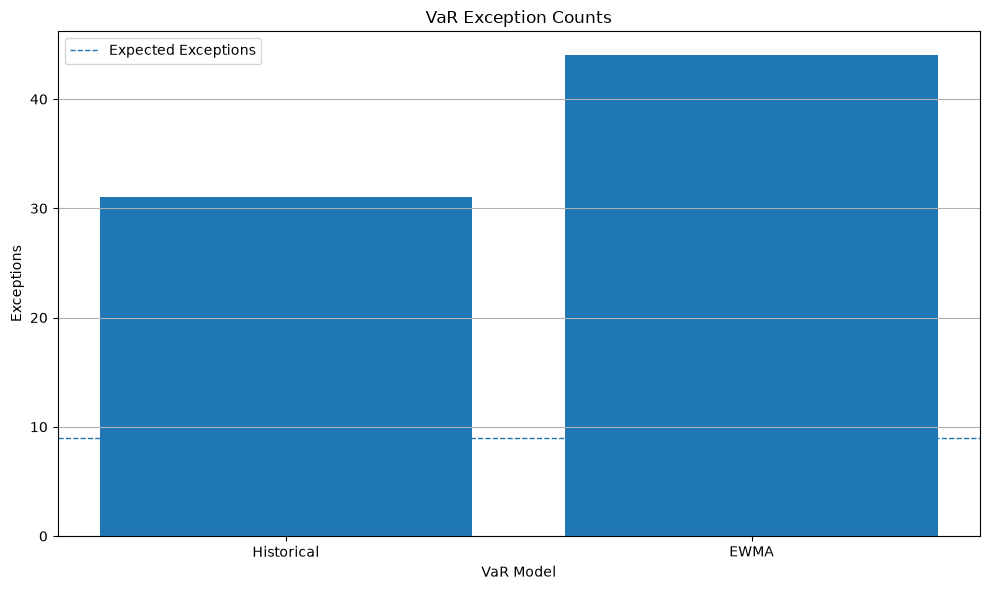

In [143]:
exception_counts = (
    results_df[
        [
            "Model",
            "Exceptions"
        ]
    ]
)

plt.figure(figsize=(10, 6))

plt.bar(
    exception_counts["Model"],
    exception_counts["Exceptions"]
)

expected = (
    len(backtest_df)
    * ALPHA
)

plt.axhline(
    expected,
    linestyle="--",
    linewidth=1,
    label="Expected Exceptions"
)

plt.title(
    "VaR Exception Counts"
)

plt.xlabel("VaR Model")
plt.ylabel("Exceptions")

plt.legend()

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()

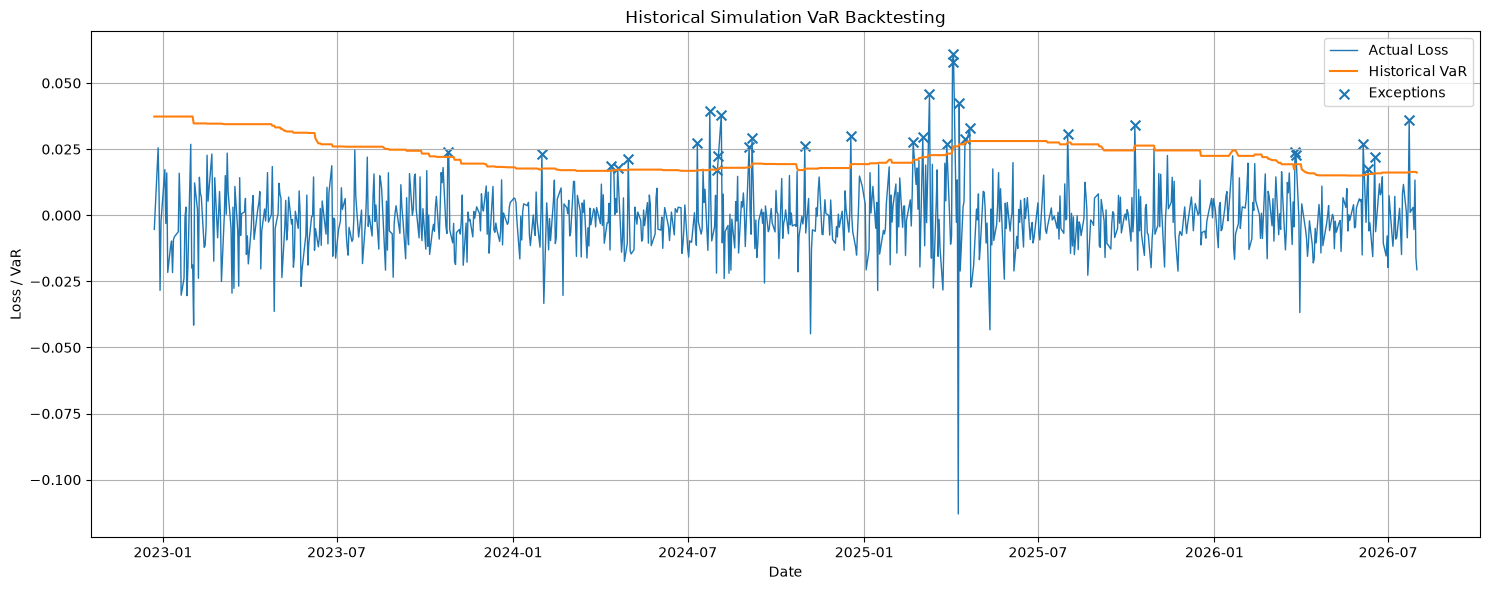

In [144]:
plt.figure(figsize=(15, 6))

plt.plot(
    backtest_df["Date"],
    backtest_df["Actual Loss"],
    label="Actual Loss",
    linewidth=1
)

plt.plot(
    backtest_df["Date"],
    backtest_df["Historical VaR"],
    label="Historical VaR"
)

exceptions = (
    backtest_df["Historical Exception"] == 1
)

plt.scatter(
    backtest_df.loc[
        exceptions,
        "Date"
    ],
    backtest_df.loc[
        exceptions,
        "Actual Loss"
    ],
    marker="x",
    s=50,
    label="Exceptions"
)

plt.title(
    "Historical Simulation VaR Backtesting"
)

plt.xlabel("Date")
plt.ylabel("Loss / VaR")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

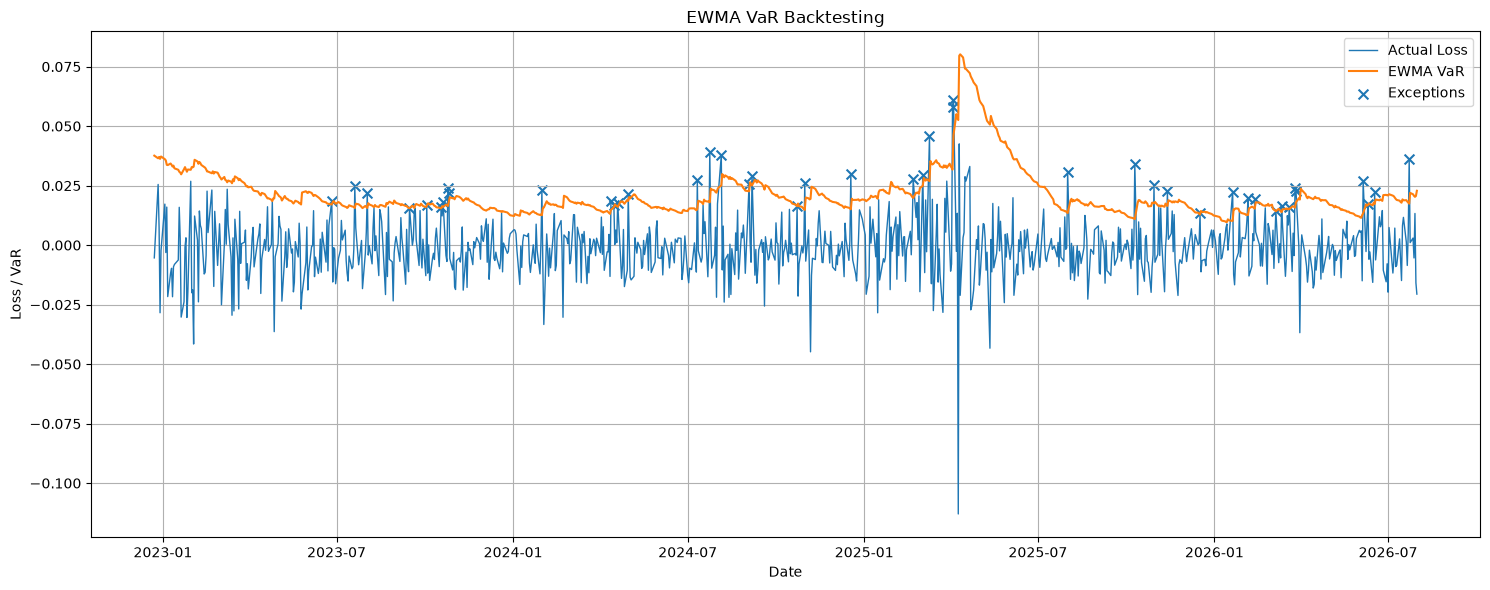

In [145]:
plt.figure(figsize=(15, 6))

plt.plot(
    backtest_df["Date"],
    backtest_df["Actual Loss"],
    label="Actual Loss",
    linewidth=1
)

plt.plot(
    backtest_df["Date"],
    backtest_df["EWMA VaR"],
    label="EWMA VaR"
)

exceptions = (
    backtest_df["EWMA Exception"] == 1
)

plt.scatter(
    backtest_df.loc[
        exceptions,
        "Date"
    ],
    backtest_df.loc[
        exceptions,
        "Actual Loss"
    ],
    marker="x",
    s=50,
    label="Exceptions"
)

plt.title(
    "EWMA VaR Backtesting"
)

plt.xlabel("Date")
plt.ylabel("Loss / VaR")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [146]:
results_path = (
    RISK_PATH / "backtest_results.csv"
)

observations_path = (
    RISK_PATH / "backtest_observations.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

backtest_df.to_csv(
    observations_path,
    index=False
)

print(
    "Saved:",
    results_path
)

print(
    "Saved:",
    observations_path
)

Saved: C:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk\data\risk\backtest_results.csv
Saved: C:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk\data\risk\backtest_observations.csv


In [147]:
print("=" * 80)
print("PHASE 8 — VaR BACKTESTING")
print("=" * 80)

print(
    f"Confidence Level : {CONFIDENCE_LEVEL:.0%}"
)

print(
    f"Estimation Window: {ESTIMATION_WINDOW} days"
)

print(
    f"OOS Observations : {len(backtest_df)}"
)

print("=" * 80)

for _, row in results_df.iterrows():

    print(
        f"\n{row['Model']}"
    )

    print(
        f"Exceptions: "
        f"{row['Exceptions']}"
    )

    print(
        f"Expected: "
        f"{row['Expected Exceptions']:.2f}"
    )

    print(
        f"Exception Ratio: "
        f"{row['Exception Ratio']:.2%}"
    )

    print(
        f"Kupiec POF: "
        f"{'PASS' if row['Kupiec Pass'] else 'FAIL'}"
    )

    print(
        f"Kupiec p-value: "
        f"{row['Kupiec p-value']:.4f}"
    )

    print(
        f"Independence: "
        f"{'PASS' if row['Independence Pass'] else 'FAIL'}"
    )

    print(
        f"Independence p-value: "
        f"{row['Independence p-value']:.4f}"
    )

    print(
        f"Conditional Coverage: "
        f"{'PASS' if row['Conditional Coverage Pass'] else 'FAIL'}"
    )

    print(
        f"Conditional Coverage p-value: "
        f"{row['Conditional Coverage p-value']:.4f}"
    )

    print(
        f"Basel Zone: "
        f"{row['Basel Zone']}"
    )

print("\n" + "=" * 80)
print("PHASE 8 COMPLETE")
print("=" * 80)

PHASE 8 — VaR BACKTESTING
Confidence Level : 99%
Estimation Window: 750 days
OOS Observations : 902

Historical
Exceptions: 31
Expected: 9.02
Exception Ratio: 3.44%
Kupiec POF: FAIL
Kupiec p-value: 0.0000
Independence: FAIL
Independence p-value: 0.0212
Conditional Coverage: FAIL
Conditional Coverage p-value: 0.0000
Basel Zone: N/A

EWMA
Exceptions: 44
Expected: 9.02
Exception Ratio: 4.88%
Kupiec POF: FAIL
Kupiec p-value: 0.0000
Independence: PASS
Independence p-value: 0.2303
Conditional Coverage: FAIL
Conditional Coverage p-value: 0.0000
Basel Zone: N/A

PHASE 8 COMPLETE


In [148]:
garch_vol_df.columns.tolist()

['Date', 'Portfolio Return', 'Conditional Volatility', 'Standardized Residual']

In [149]:
gjr_vol_df.columns.tolist()

['Date', 'GJR-GARCH Conditional Volatility', 'Standardized Residual']

In [150]:
garch_scaled_df.columns.tolist()

['Date',
 'Portfolio Return',
 'Conditional Volatility',
 'Scaling Factor',
 'GARCH Scaled Return']

In [151]:
gjr_scaled_df.columns.tolist()

['Date', 'GJR-GARCH Scaled Return']

In [152]:
garch_vol_df = pd.read_csv(
    PROCESSED_PATH / "garch_volatility.csv"
)

garch_scaled_df = pd.read_csv(
    PROCESSED_PATH / "garch_scaled_returns.csv"
)

print("GARCH volatility columns:")
print(garch_vol_df.columns.tolist())

print("\nGARCH scaled returns columns:")
print(garch_scaled_df.columns.tolist())

display(garch_vol_df.head())
display(garch_scaled_df.head())

GARCH volatility columns:
['Date', 'Portfolio Return', 'Conditional Volatility', 'Standardized Residual']

GARCH scaled returns columns:
['Date', 'Portfolio Return', 'Conditional Volatility', 'Scaling Factor', 'GARCH Scaled Return']


,Date,Portfolio Return,Conditional Volatility,Standardized Residual
0,2020-01-03,-0.009045,0.020835,-0.494645
1,2020-01-06,0.009246,0.019837,0.402521
2,2020-01-07,-0.000913,0.018811,-0.115564
3,2020-01-08,0.009735,0.017695,0.478924
4,2020-01-09,0.009290,0.016892,0.475313


,Date,Portfolio Return,Conditional Volatility,Scaling Factor,GARCH Scaled Return
0,2020-01-03,-0.009045,0.020835,0.706972,-0.006395
1,2020-01-06,0.009246,0.019837,0.742526,0.006865
2,2020-01-07,-0.000913,0.018811,0.783060,-0.000715
3,2020-01-08,0.009735,0.017695,0.832451,0.008104
4,2020-01-09,0.009290,0.016892,0.872017,0.008101


In [153]:
gjr_vol_df = pd.read_csv(
    PROCESSED_PATH / "gjr_garch_volatility.csv"
)

gjr_scaled_df = pd.read_csv(
    PROCESSED_PATH / "gjr_garch_scaled_returns.csv"
)

print("GJR-GARCH volatility columns:")
print(gjr_vol_df.columns.tolist())

print("\nGJR-GARCH scaled returns columns:")
print(gjr_scaled_df.columns.tolist())

display(gjr_vol_df.head())
display(gjr_scaled_df.head())

GJR-GARCH volatility columns:
['Date', 'GJR-GARCH Conditional Volatility', 'Standardized Residual']

GJR-GARCH scaled returns columns:
['Date', 'GJR-GARCH Scaled Return']


,Date,GJR-GARCH Conditional Volatility,Standardized Residual
0,2020-01-03,0.020781,-0.475292
1,2020-01-06,0.020171,0.417127
2,2020-01-07,0.019271,-0.090554
3,2020-01-08,0.018425,0.483211
4,2020-01-09,0.017640,0.479466


,Date,GJR-GARCH Scaled Return
0,2020-01-03,-0.005987
1,2020-01-06,0.006305
2,2020-01-07,-0.000652
3,2020-01-08,0.007268
4,2020-01-09,0.007244


In [154]:
# Convert dates
garch_scaled_df["Date"] = pd.to_datetime(
    garch_scaled_df["Date"],
    errors="coerce"
)

# Convert numeric columns
garch_numeric_columns = [
    "Portfolio Return",
    "Conditional Volatility",
    "Scaling Factor",
    "GARCH Scaled Return"
]

for column in garch_numeric_columns:

    garch_scaled_df[column] = pd.to_numeric(
        garch_scaled_df[column],
        errors="coerce"
    )

# Clean
garch_scaled_df = (
    garch_scaled_df
    .dropna(
        subset=[
            "Date",
            "GARCH Scaled Return",
            "Scaling Factor"
        ]
    )
    .sort_values("Date")
    .reset_index(drop=True)
)

print(
    "GARCH observations:",
    len(garch_scaled_df)
)

display(
    garch_scaled_df.head()
)

GARCH observations: 1652


,Date,Portfolio Return,Conditional Volatility,Scaling Factor,GARCH Scaled Return
0,2020-01-03,-0.009045,0.020835,0.706972,-0.006395
1,2020-01-06,0.009246,0.019837,0.742526,0.006865
2,2020-01-07,-0.000913,0.018811,0.783060,-0.000715
3,2020-01-08,0.009735,0.017695,0.832451,0.008104
4,2020-01-09,0.009290,0.016892,0.872017,0.008101


In [155]:
# Convert dates
gjr_scaled_df["Date"] = pd.to_datetime(
    gjr_scaled_df["Date"],
    errors="coerce"
)

# Convert numeric columns
gjr_scaled_df["GJR-GARCH Scaled Return"] = pd.to_numeric(
    gjr_scaled_df["GJR-GARCH Scaled Return"],
    errors="coerce"
)

# Clean
gjr_scaled_df = (
    gjr_scaled_df
    .dropna(
        subset=[
            "Date",
            "GJR-GARCH Scaled Return"
        ]
    )
    .sort_values("Date")
    .reset_index(drop=True)
)

print(
    "GJR-GARCH observations:",
    len(gjr_scaled_df)
)

display(
    gjr_scaled_df.head()
)

GJR-GARCH observations: 1652


,Date,GJR-GARCH Scaled Return
0,2020-01-03,-0.005987
1,2020-01-06,0.006305
2,2020-01-07,-0.000652
3,2020-01-08,0.007268
4,2020-01-09,0.007244


In [156]:
GARCH_ESTIMATION_WINDOW = 750

garch_backtest_rows = []

for i in range(
    GARCH_ESTIMATION_WINDOW,
    len(garch_scaled_df)
):

    historical_scaled_returns = (
        garch_scaled_df[
            "GARCH Scaled Return"
        ]
        .iloc[
            i - GARCH_ESTIMATION_WINDOW:i
        ]
    )

    current_scaling_factor = (
        garch_scaled_df.loc[
            i,
            "Scaling Factor"
        ]
    )

    current_date = (
        garch_scaled_df.loc[
            i,
            "Date"
        ]
    )

    if (
        pd.isna(current_scaling_factor)
        or current_scaling_factor == 0
    ):
        continue

    # 1% lower-tail quantile
    scaled_quantile = np.quantile(
        historical_scaled_returns,
        ALPHA
    )

    # Convert to positive loss VaR
    scaled_var = -scaled_quantile

    # Transform back to original return scale
    garch_var = (
        scaled_var
        / abs(current_scaling_factor)
    )

    garch_backtest_rows.append({
        "Date": current_date,
        "GARCH VaR": garch_var
    })


garch_backtest_df = pd.DataFrame(
    garch_backtest_rows
)

print(
    "GARCH daily VaR observations:",
    len(garch_backtest_df)
)

display(
    garch_backtest_df.head()
)

GARCH daily VaR observations: 902


,Date,GARCH VaR
0,2022-12-23,0.054720
1,2022-12-27,0.051402
2,2022-12-28,0.053933
3,2022-12-29,0.051898
4,2022-12-30,0.054537


In [157]:
# Calculate GJR-GARCH scaling factor

gjr_scaled_df = gjr_scaled_df.merge(
    portfolio_df[
        [
            "Date",
            "Actual Return"
        ]
    ],
    on="Date",
    how="left"
)

gjr_scaled_df["GJR Scaling Factor"] = np.where(
    gjr_scaled_df["Actual Return"].abs() > 1e-12,

    gjr_scaled_df[
        "GJR-GARCH Scaled Return"
    ]
    / gjr_scaled_df[
        "Actual Return"
    ],

    np.nan
)

display(
    gjr_scaled_df[
        [
            "Date",
            "Actual Return",
            "GJR-GARCH Scaled Return",
            "GJR Scaling Factor"
        ]
    ].head(10)
)

,Date,Actual Return,GJR-GARCH Scaled Return,GJR Scaling Factor
0,2020-01-03,-0.006352,-0.005987,0.942475
1,2020-01-06,0.010729,0.006305,0.587674
2,2020-01-07,0.000712,-0.000652,-0.914804
3,2020-01-08,0.010445,0.007268,0.695807
4,2020-01-09,0.005718,0.007244,1.266726
5,2020-01-10,-0.002367,-0.001161,0.490507
6,2020-01-13,0.017252,0.014495,0.840196
7,2020-01-14,-0.003476,-0.005893,1.695501
8,2020-01-15,-0.001877,-0.002057,1.096184
9,2020-01-16,0.006784,0.008810,1.298644


In [158]:
GJR_ESTIMATION_WINDOW = 750

gjr_backtest_rows = []

for i in range(
    GJR_ESTIMATION_WINDOW,
    len(gjr_scaled_df)
):

    historical_scaled_returns = (
        gjr_scaled_df[
            "GJR-GARCH Scaled Return"
        ]
        .iloc[
            i - GJR_ESTIMATION_WINDOW:i
        ]
    )

    current_scaling_factor = (
        gjr_scaled_df.loc[
            i,
            "GJR Scaling Factor"
        ]
    )

    current_date = (
        gjr_scaled_df.loc[
            i,
            "Date"
        ]
    )

    if (
        pd.isna(current_scaling_factor)
        or current_scaling_factor == 0
    ):
        continue

    scaled_quantile = np.quantile(
        historical_scaled_returns,
        ALPHA
    )

    scaled_var = -scaled_quantile

    gjr_var = (
        scaled_var
        / abs(current_scaling_factor)
    )

    gjr_backtest_rows.append({
        "Date": current_date,
        "GJR-GARCH VaR": gjr_var
    })


gjr_backtest_df = pd.DataFrame(
    gjr_backtest_rows
)

print(
    "GJR-GARCH daily VaR observations:",
    len(gjr_backtest_df)
)

display(
    gjr_backtest_df.head()
)

GJR-GARCH daily VaR observations: 902


,Date,GJR-GARCH VaR
0,2022-12-23,0.092708
1,2022-12-27,0.059260
2,2022-12-28,0.041004
3,2022-12-29,0.061297
4,2022-12-30,0.112088


In [159]:
backtest_df = backtest_df.merge(
    garch_backtest_df,
    on="Date",
    how="left"
)

backtest_df = backtest_df.merge(
    gjr_backtest_df,
    on="Date",
    how="left"
)

backtest_df = (
    backtest_df
    .sort_values("Date")
    .reset_index(drop=True)
)

print(
    "Final backtest shape:",
    backtest_df.shape
)

display(
    backtest_df.head(10)
)

Final backtest shape: (902, 9)


,Date,Actual Return,Actual Loss,Historical VaR,EWMA VaR,Historical Exception,EWMA Exception,GARCH VaR,GJR-GARCH VaR
0,2022-12-23,0.005357,-0.005357,0.037331,0.037602,0,0,0.054720,0.092708
1,2022-12-27,-0.025499,0.025499,0.037331,0.036490,0,0,0.051402,0.059260
2,2022-12-28,-0.007419,0.007419,0.037331,0.037052,0,0,0.053933,0.041004
3,2022-12-29,0.028412,-0.028412,0.037331,0.036260,0,0,0.051898,0.061297
4,2022-12-30,0.002258,-0.002258,0.037331,0.037253,0,0,0.054537,0.112088
5,2023-01-03,-0.017240,0.017240,0.037331,0.036122,0,0,0.051193,0.066046
6,2023-01-04,0.003110,-0.003110,0.037331,0.035595,0,0,0.050212,0.159348
7,2023-01-05,-0.015989,0.015989,0.037331,0.033748,0,0,0.047220,0.046680
8,2023-01-06,0.021615,-0.021615,0.037331,0.033636,0,0,0.047861,0.047685
9,2023-01-09,0.011733,-0.011733,0.037331,0.034296,0,0,0.049878,0.046115


In [160]:
var_columns = [
    "Historical VaR",
    "EWMA VaR",
    "GARCH VaR",
    "GJR-GARCH VaR"
]

print(
    backtest_df[
        [
            "Date",
            "Actual Loss"
        ] + var_columns
    ].head(10)
)

        Date  Actual Loss  Historical VaR  EWMA VaR  GARCH VaR  GJR-GARCH VaR
0 2022-12-23    -0.005357        0.037331  0.037602   0.054720       0.092708
1 2022-12-27     0.025499        0.037331  0.036490   0.051402       0.059260
2 2022-12-28     0.007419        0.037331  0.037052   0.053933       0.041004
3 2022-12-29    -0.028412        0.037331  0.036260   0.051898       0.061297
4 2022-12-30    -0.002258        0.037331  0.037253   0.054537       0.112088
5 2023-01-03     0.017240        0.037331  0.036122   0.051193       0.066046
6 2023-01-04    -0.003110        0.037331  0.035595   0.050212       0.159348
7 2023-01-05     0.015989        0.037331  0.033748   0.047220       0.046680
8 2023-01-06    -0.021615        0.037331  0.033636   0.047861       0.047685
9 2023-01-09    -0.011733        0.037331  0.034296   0.049878       0.046115


In [161]:
print(
    backtest_df[
        [
            "Actual Loss"
        ] + var_columns
    ].isna().sum()
)

Actual Loss       0
Historical VaR    0
EWMA VaR          0
GARCH VaR         0
GJR-GARCH VaR     0
dtype: int64


In [162]:
backtest_complete_df = (
    backtest_df[
        [
            "Date",
            "Actual Return",
            "Actual Loss"
        ] + var_columns
    ]
    .dropna()
    .reset_index(drop=True)
)

print(
    "Complete backtest observations:",
    len(backtest_complete_df)
)

display(
    backtest_complete_df.head()
)

Complete backtest observations: 902


,Date,Actual Return,Actual Loss,Historical VaR,EWMA VaR,GARCH VaR,GJR-GARCH VaR
0,2022-12-23,0.005357,-0.005357,0.037331,0.037602,0.054720,0.092708
1,2022-12-27,-0.025499,0.025499,0.037331,0.036490,0.051402,0.059260
2,2022-12-28,-0.007419,0.007419,0.037331,0.037052,0.053933,0.041004
3,2022-12-29,0.028412,-0.028412,0.037331,0.036260,0.051898,0.061297
4,2022-12-30,0.002258,-0.002258,0.037331,0.037253,0.054537,0.112088


In [163]:
for model in var_columns:

    exception_column = (
        model.replace(
            " VaR",
            ""
        )
        + " Exception"
    )

    backtest_complete_df[
        exception_column
    ] = (
        backtest_complete_df[
            "Actual Loss"
        ]
        >
        backtest_complete_df[
            model
        ]
    ).astype(int)


display(
    backtest_complete_df.head()
)

,Date,Actual Return,Actual Loss,Historical VaR,EWMA VaR,GARCH VaR,GJR-GARCH VaR,Historical Exception,EWMA Exception,GARCH Exception,GJR-GARCH Exception
0,2022-12-23,0.005357,-0.005357,0.037331,0.037602,0.054720,0.092708,0,0,0,0
1,2022-12-27,-0.025499,0.025499,0.037331,0.036490,0.051402,0.059260,0,0,0,0
2,2022-12-28,-0.007419,0.007419,0.037331,0.037052,0.053933,0.041004,0,0,0,0
3,2022-12-29,0.028412,-0.028412,0.037331,0.036260,0.051898,0.061297,0,0,0,0
4,2022-12-30,0.002258,-0.002258,0.037331,0.037253,0.054537,0.112088,0,0,0,0


In [164]:
exception_summary = []

for model in var_columns:

    exception_column = (
        model.replace(
            " VaR",
            ""
        )
        + " Exception"
    )

    count = int(
        backtest_complete_df[
            exception_column
        ].sum()
    )

    exception_summary.append({
        "Model": model.replace(
            " VaR",
            ""
        ),
        "Exceptions": count,
        "Observations": len(
            backtest_complete_df
        ),
        "Expected Exceptions": (
            len(backtest_complete_df)
            * ALPHA
        )
    })


exception_summary_df = pd.DataFrame(
    exception_summary
)

display(
    exception_summary_df
)

,Model,Exceptions,Observations,Expected Exceptions
0,Historical,31,902,9.02
1,EWMA,44,902,9.02
2,GARCH,11,902,9.02
3,GJR-GARCH,11,902,9.02


In [165]:
def kupiec_pof_test(
    exceptions,
    confidence_level=0.99
):

    exceptions = np.asarray(
        exceptions,
        dtype=int
    )

    n = len(exceptions)

    x = int(
        exceptions.sum()
    )

    if n == 0:

        return {
            "LR POF": np.nan,
            "p-value": np.nan,
            "Pass": False
        }

    p = 1 - confidence_level

    phat = x / n

    eps = 1e-12

    p_safe = np.clip(
        p,
        eps,
        1 - eps
    )

    phat_safe = np.clip(
        phat,
        eps,
        1 - eps
    )

    log_likelihood_null = (
        x * np.log(p_safe)
        +
        (n - x)
        * np.log(1 - p_safe)
    )

    log_likelihood_alt = (
        x * np.log(phat_safe)
        +
        (n - x)
        * np.log(1 - phat_safe)
    )

    lr_pof = -2 * (
        log_likelihood_null
        -
        log_likelihood_alt
    )

    p_value = chi2.sf(
        lr_pof,
        df=1
    )

    return {
        "LR POF": lr_pof,
        "p-value": p_value,
        "Pass": p_value >= 0.05
    }

In [166]:
def christoffersen_independence_test(
    exceptions
):

    exceptions = np.asarray(
        exceptions,
        dtype=int
    )

    if len(exceptions) < 2:

        return {
            "LR Independence": np.nan,
            "p-value": np.nan,
            "Pass": False
        }

    n00 = 0
    n01 = 0
    n10 = 0
    n11 = 0

    for i in range(
        1,
        len(exceptions)
    ):

        previous = exceptions[i - 1]
        current = exceptions[i]

        if previous == 0 and current == 0:
            n00 += 1

        elif previous == 0 and current == 1:
            n01 += 1

        elif previous == 1 and current == 0:
            n10 += 1

        elif previous == 1 and current == 1:
            n11 += 1

    total = (
        n00
        + n01
        + n10
        + n11
    )

    if total == 0:

        return {
            "LR Independence": np.nan,
            "p-value": np.nan,
            "Pass": False
        }

    n0 = n00 + n01
    n1 = n10 + n11

    pi01 = (
        n01 / n0
        if n0 > 0
        else 0
    )

    pi11 = (
        n11 / n1
        if n1 > 0
        else 0
    )

    pi = (
        (n01 + n11)
        / total
    )

    eps = 1e-12

    pi = np.clip(
        pi,
        eps,
        1 - eps
    )

    pi01 = np.clip(
        pi01,
        eps,
        1 - eps
    )

    pi11 = np.clip(
        pi11,
        eps,
        1 - eps
    )

    log_likelihood_independent = (
        (n00 + n10)
        * np.log(1 - pi)
        +
        (n01 + n11)
        * np.log(pi)
    )

    log_likelihood_markov = (
        n00 * np.log(1 - pi01)
        +
        n01 * np.log(pi01)
        +
        n10 * np.log(1 - pi11)
        +
        n11 * np.log(pi11)
    )

    lr_independence = -2 * (
        log_likelihood_independent
        -
        log_likelihood_markov
    )

    p_value = chi2.sf(
        lr_independence,
        df=1
    )

    return {
        "LR Independence":
            lr_independence,

        "p-value":
            p_value,

        "Pass":
            p_value >= 0.05
    }

In [167]:
def christoffersen_conditional_coverage_test(
    exceptions,
    confidence_level=0.99
):

    kupiec = kupiec_pof_test(
        exceptions,
        confidence_level
    )

    independence = (
        christoffersen_independence_test(
            exceptions
        )
    )

    lr_cc = (
        kupiec["LR POF"]
        +
        independence[
            "LR Independence"
        ]
    )

    p_value = chi2.sf(
        lr_cc,
        df=2
    )

    return {
        "LR Conditional Coverage":
            lr_cc,

        "p-value":
            p_value,

        "Pass":
            p_value >= 0.05
    }

In [168]:
def basel_traffic_light(
    exceptions
):

    exceptions = np.asarray(
        exceptions,
        dtype=int
    )

    n = len(exceptions)

    x = int(
        exceptions.sum()
    )

    if n != 250:

        return {
            "Zone": "N/A",
            "Exceptions": x,
            "Observations": n
        }

    if x <= 4:

        zone = "Green"

    elif x <= 9:

        zone = "Yellow"

    else:

        zone = "Red"

    return {
        "Zone": zone,
        "Exceptions": x,
        "Observations": n
    }

In [169]:
def run_model_backtest(
    df,
    var_column,
    confidence_level=0.99
):

    data = df[
        [
            "Actual Loss",
            var_column
        ]
    ].dropna()

    exceptions = (
        data["Actual Loss"]
        >
        data[var_column]
    ).astype(int).values

    n = len(exceptions)

    x = int(
        exceptions.sum()
    )

    expected_exceptions = (
        n
        * (1 - confidence_level)
    )

    exception_ratio = (
        x / n
        if n > 0
        else np.nan
    )

    kupiec = kupiec_pof_test(
        exceptions,
        confidence_level
    )

    independence = (
        christoffersen_independence_test(
            exceptions
        )
    )

    conditional = (
        christoffersen_conditional_coverage_test(
            exceptions,
            confidence_level
        )
    )

    basel = basel_traffic_light(
        exceptions
    )

    return {
        "Model":
            var_column.replace(
                " VaR",
                ""
            ),

        "Observations":
            n,

        "Exceptions":
            x,

        "Expected Exceptions":
            expected_exceptions,

        "Exception Ratio":
            exception_ratio,

        "LR POF":
            kupiec["LR POF"],

        "Kupiec p-value":
            kupiec["p-value"],

        "Kupiec Pass":
            kupiec["Pass"],

        "LR Independence":
            independence[
                "LR Independence"
            ],

        "Independence p-value":
            independence[
                "p-value"
            ],

        "Independence Pass":
            independence[
                "Pass"
            ],

        "LR Conditional Coverage":
            conditional[
                "LR Conditional Coverage"
            ],

        "Conditional Coverage p-value":
            conditional[
                "p-value"
            ],

        "Conditional Coverage Pass":
            conditional[
                "Pass"
            ],

        "Basel Zone":
            basel["Zone"]
    }

In [170]:
results = []

for model in var_columns:

    result = run_model_backtest(
        backtest_complete_df,
        model,
        CONFIDENCE_LEVEL
    )

    results.append(result)


results_df = pd.DataFrame(
    results
)

display(
    results_df
)

,Model,Observations,Exceptions,Expected Exceptions,Exception Ratio,LR POF,Kupiec p-value,Kupiec Pass,LR Independence,Independence p-value,Independence Pass,LR Conditional Coverage,Conditional Coverage p-value,Conditional Coverage Pass,Basel Zone
0,Historical,902,31,9.02,0.034368,33.127173,8.632388e-09,False,5.312712,0.021170,False,38.439885,4.496609e-09,False,N/A
1,EWMA,902,44,9.02,0.048780,70.886081,3.784586e-17,False,1.439262,0.230259,True,72.325343,1.971293e-16,False,N/A
2,GARCH,902,11,9.02,0.012195,0.410314,5.218101e-01,True,0.271917,0.602049,True,0.682231,7.109767e-01,True,N/A
3,GJR-GARCH,902,11,9.02,0.012195,0.410314,5.218101e-01,True,0.271917,0.602049,True,0.682231,7.109767e-01,True,N/A


In [171]:
results_display = results_df.copy()

results_display[
    "Exception Ratio"
] = (
    results_display[
        "Exception Ratio"
    ] * 100
).round(2)

results_display[
    "Expected Exceptions"
] = (
    results_display[
        "Expected Exceptions"
    ].round(2)
)

for column in [
    "Kupiec p-value",
    "Independence p-value",
    "Conditional Coverage p-value"
]:

    results_display[column] = (
        results_display[column]
        .round(4)
    )

display(
    results_display
)

,Model,Observations,Exceptions,Expected Exceptions,Exception Ratio,LR POF,Kupiec p-value,Kupiec Pass,LR Independence,Independence p-value,Independence Pass,LR Conditional Coverage,Conditional Coverage p-value,Conditional Coverage Pass,Basel Zone
0,Historical,902,31,9.02,3.44,33.127173,0.0000,False,5.312712,0.0212,False,38.439885,0.000,False,N/A
1,EWMA,902,44,9.02,4.88,70.886081,0.0000,False,1.439262,0.2303,True,72.325343,0.000,False,N/A
2,GARCH,902,11,9.02,1.22,0.410314,0.5218,True,0.271917,0.6020,True,0.682231,0.711,True,N/A
3,GJR-GARCH,902,11,9.02,1.22,0.410314,0.5218,True,0.271917,0.6020,True,0.682231,0.711,True,N/A


In [172]:
results_display = results_df.copy()

results_display[
    "Exception Ratio"
] = (
    results_display[
        "Exception Ratio"
    ] * 100
).round(2)

results_display[
    "Expected Exceptions"
] = (
    results_display[
        "Expected Exceptions"
    ].round(2)
)

for column in [
    "Kupiec p-value",
    "Independence p-value",
    "Conditional Coverage p-value"
]:

    results_display[column] = (
        results_display[column]
        .round(4)
    )

display(
    results_display
)

,Model,Observations,Exceptions,Expected Exceptions,Exception Ratio,LR POF,Kupiec p-value,Kupiec Pass,LR Independence,Independence p-value,Independence Pass,LR Conditional Coverage,Conditional Coverage p-value,Conditional Coverage Pass,Basel Zone
0,Historical,902,31,9.02,3.44,33.127173,0.0000,False,5.312712,0.0212,False,38.439885,0.000,False,N/A
1,EWMA,902,44,9.02,4.88,70.886081,0.0000,False,1.439262,0.2303,True,72.325343,0.000,False,N/A
2,GARCH,902,11,9.02,1.22,0.410314,0.5218,True,0.271917,0.6020,True,0.682231,0.711,True,N/A
3,GJR-GARCH,902,11,9.02,1.22,0.410314,0.5218,True,0.271917,0.6020,True,0.682231,0.711,True,N/A


In [173]:
summary_columns = [
    "Model",
    "Observations",
    "Exceptions",
    "Expected Exceptions",
    "Exception Ratio",
    "Kupiec p-value",
    "Kupiec Pass",
    "Independence p-value",
    "Independence Pass",
    "Conditional Coverage p-value",
    "Conditional Coverage Pass",
    "Basel Zone"
]

display(
    results_display[
        summary_columns
    ]
)

,Model,Observations,Exceptions,Expected Exceptions,Exception Ratio,Kupiec p-value,Kupiec Pass,Independence p-value,Independence Pass,Conditional Coverage p-value,Conditional Coverage Pass,Basel Zone
0,Historical,902,31,9.02,3.44,0.0000,False,0.0212,False,0.000,False,N/A
1,EWMA,902,44,9.02,4.88,0.0000,False,0.2303,True,0.000,False,N/A
2,GARCH,902,11,9.02,1.22,0.5218,True,0.6020,True,0.711,True,N/A
3,GJR-GARCH,902,11,9.02,1.22,0.5218,True,0.6020,True,0.711,True,N/A


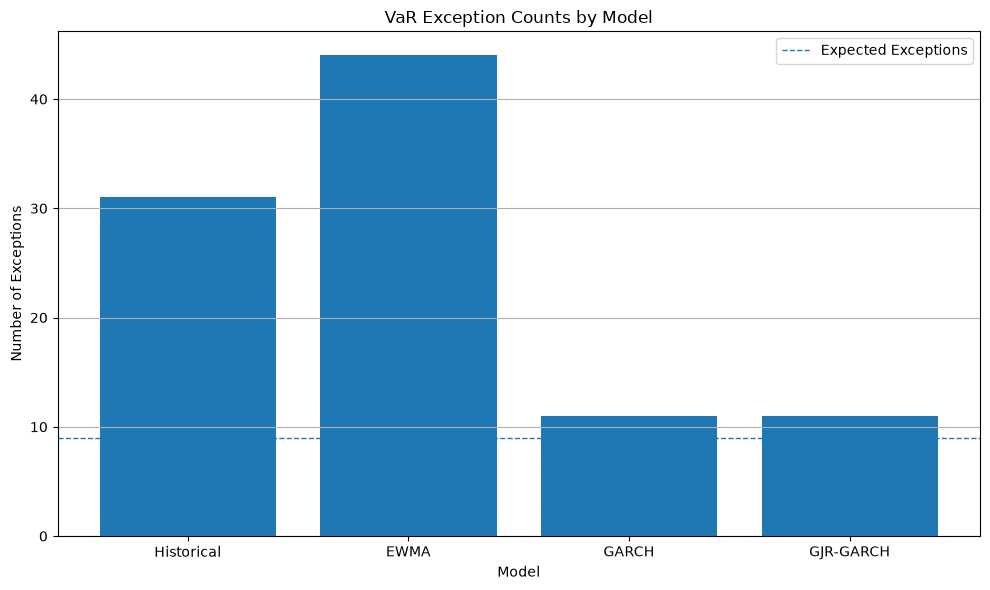

In [174]:
exception_chart_df = results_df[
    [
        "Model",
        "Exceptions"
    ]
].copy()

plt.figure(figsize=(10, 6))

plt.bar(
    exception_chart_df["Model"],
    exception_chart_df["Exceptions"]
)

expected_exceptions = (
    len(backtest_complete_df)
    * ALPHA
)

plt.axhline(
    expected_exceptions,
    linestyle="--",
    linewidth=1,
    label="Expected Exceptions"
)

plt.title(
    "VaR Exception Counts by Model"
)

plt.xlabel("Model")
plt.ylabel("Number of Exceptions")

plt.legend()

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()

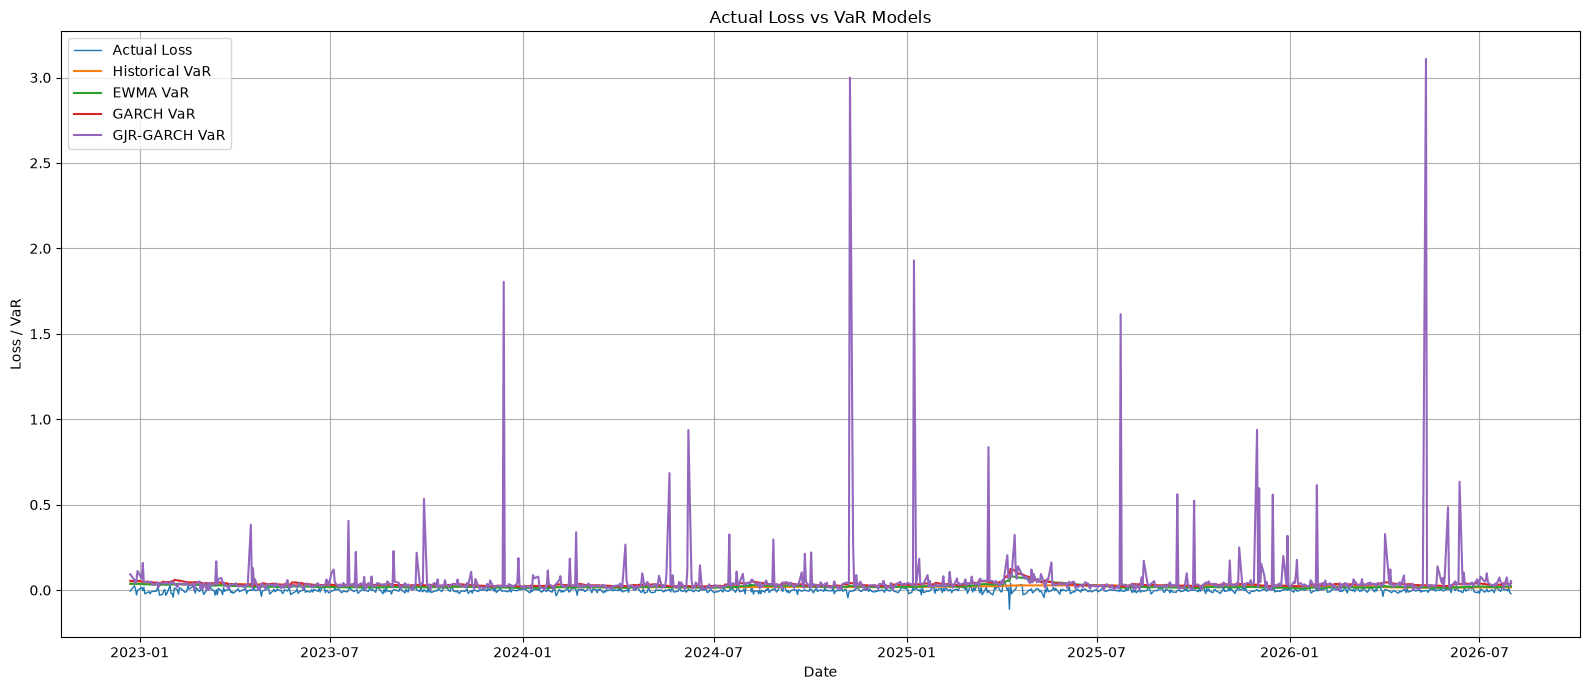

In [175]:
plt.figure(figsize=(16, 7))

plt.plot(
    backtest_complete_df["Date"],
    backtest_complete_df["Actual Loss"],
    label="Actual Loss",
    linewidth=1
)

for model in var_columns:

    plt.plot(
        backtest_complete_df["Date"],
        backtest_complete_df[model],
        label=model
    )

plt.title(
    "Actual Loss vs VaR Models"
)

plt.xlabel("Date")
plt.ylabel("Loss / VaR")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

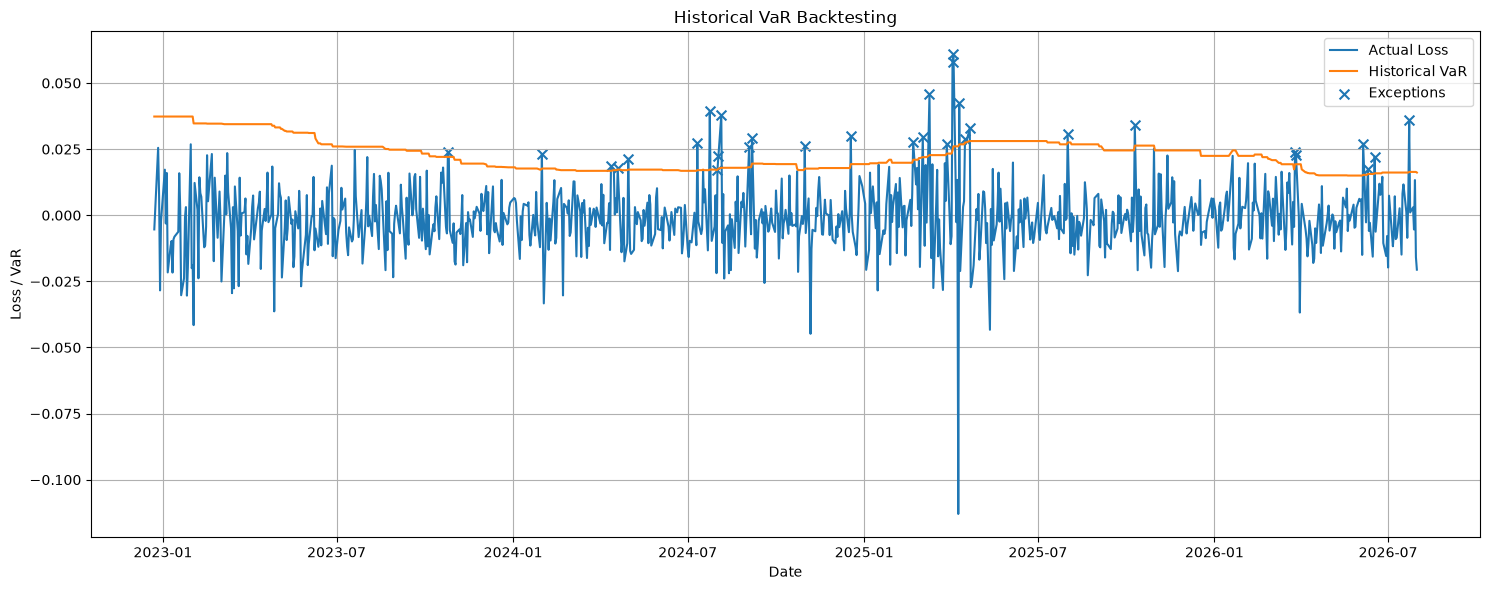

In [176]:
plt.figure(figsize=(15, 6))

plt.plot(
    backtest_complete_df["Date"],
    backtest_complete_df["Actual Loss"],
    label="Actual Loss"
)

plt.plot(
    backtest_complete_df["Date"],
    backtest_complete_df["Historical VaR"],
    label="Historical VaR"
)

exceptions = (
    backtest_complete_df["Actual Loss"]
    >
    backtest_complete_df["Historical VaR"]
)

plt.scatter(
    backtest_complete_df.loc[
        exceptions,
        "Date"
    ],
    backtest_complete_df.loc[
        exceptions,
        "Actual Loss"
    ],
    marker="x",
    s=50,
    label="Exceptions"
)

plt.title(
    "Historical VaR Backtesting"
)

plt.xlabel("Date")
plt.ylabel("Loss / VaR")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

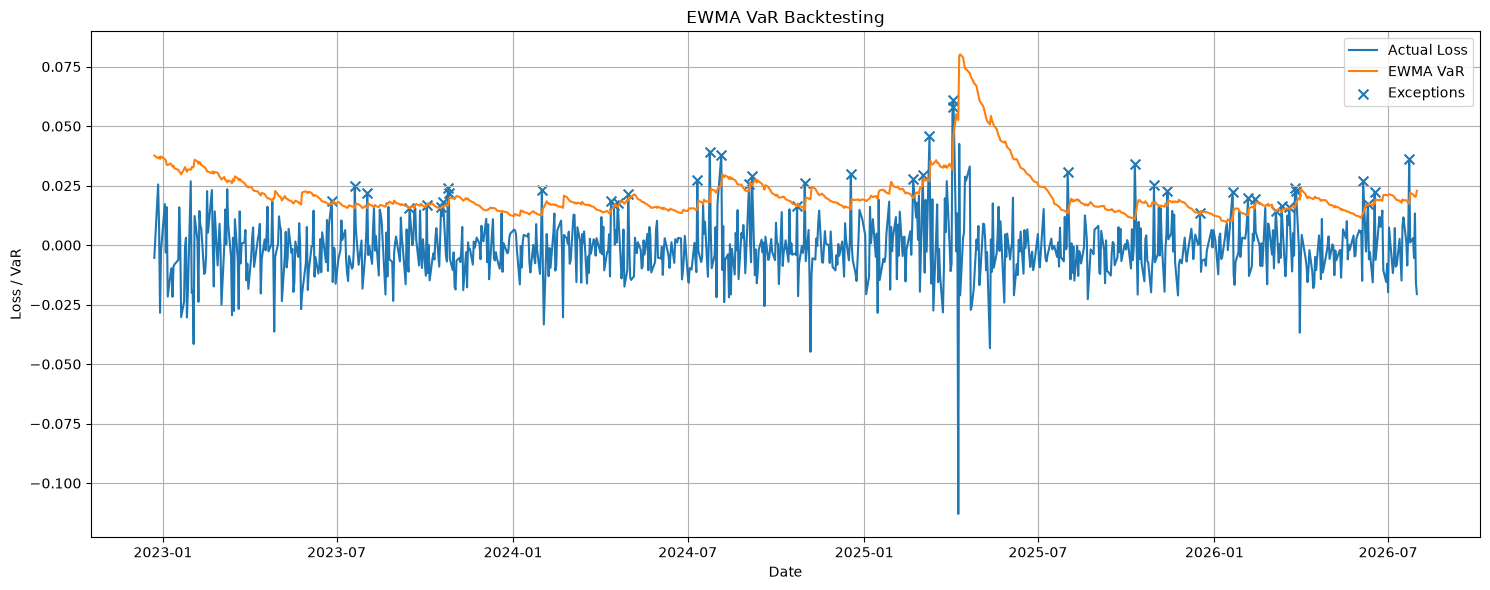

In [177]:
plt.figure(figsize=(15, 6))

plt.plot(
    backtest_complete_df["Date"],
    backtest_complete_df["Actual Loss"],
    label="Actual Loss"
)

plt.plot(
    backtest_complete_df["Date"],
    backtest_complete_df["EWMA VaR"],
    label="EWMA VaR"
)

exceptions = (
    backtest_complete_df["Actual Loss"]
    >
    backtest_complete_df["EWMA VaR"]
)

plt.scatter(
    backtest_complete_df.loc[
        exceptions,
        "Date"
    ],
    backtest_complete_df.loc[
        exceptions,
        "Actual Loss"
    ],
    marker="x",
    s=50,
    label="Exceptions"
)

plt.title(
    "EWMA VaR Backtesting"
)

plt.xlabel("Date")
plt.ylabel("Loss / VaR")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

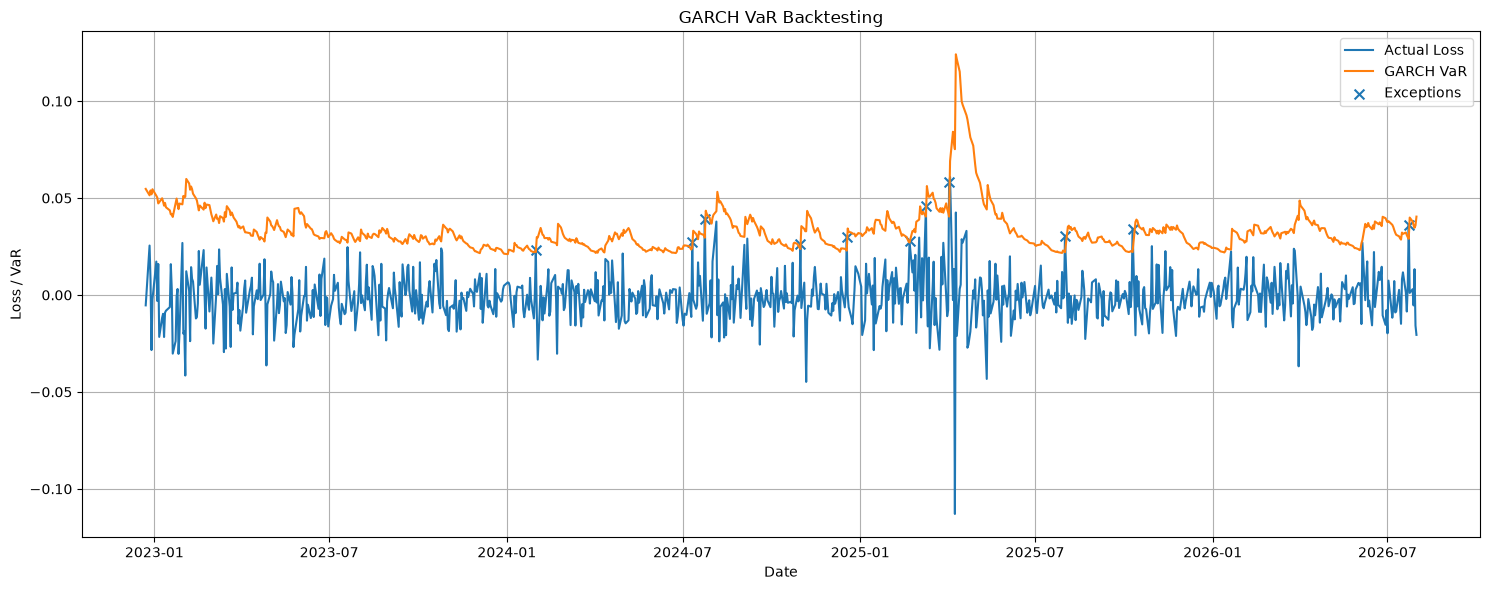

In [178]:
plt.figure(figsize=(15, 6))

plt.plot(
    backtest_complete_df["Date"],
    backtest_complete_df["Actual Loss"],
    label="Actual Loss"
)

plt.plot(
    backtest_complete_df["Date"],
    backtest_complete_df["GARCH VaR"],
    label="GARCH VaR"
)

exceptions = (
    backtest_complete_df["Actual Loss"]
    >
    backtest_complete_df["GARCH VaR"]
)

plt.scatter(
    backtest_complete_df.loc[
        exceptions,
        "Date"
    ],
    backtest_complete_df.loc[
        exceptions,
        "Actual Loss"
    ],
    marker="x",
    s=50,
    label="Exceptions"
)

plt.title(
    "GARCH VaR Backtesting"
)

plt.xlabel("Date")
plt.ylabel("Loss / VaR")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

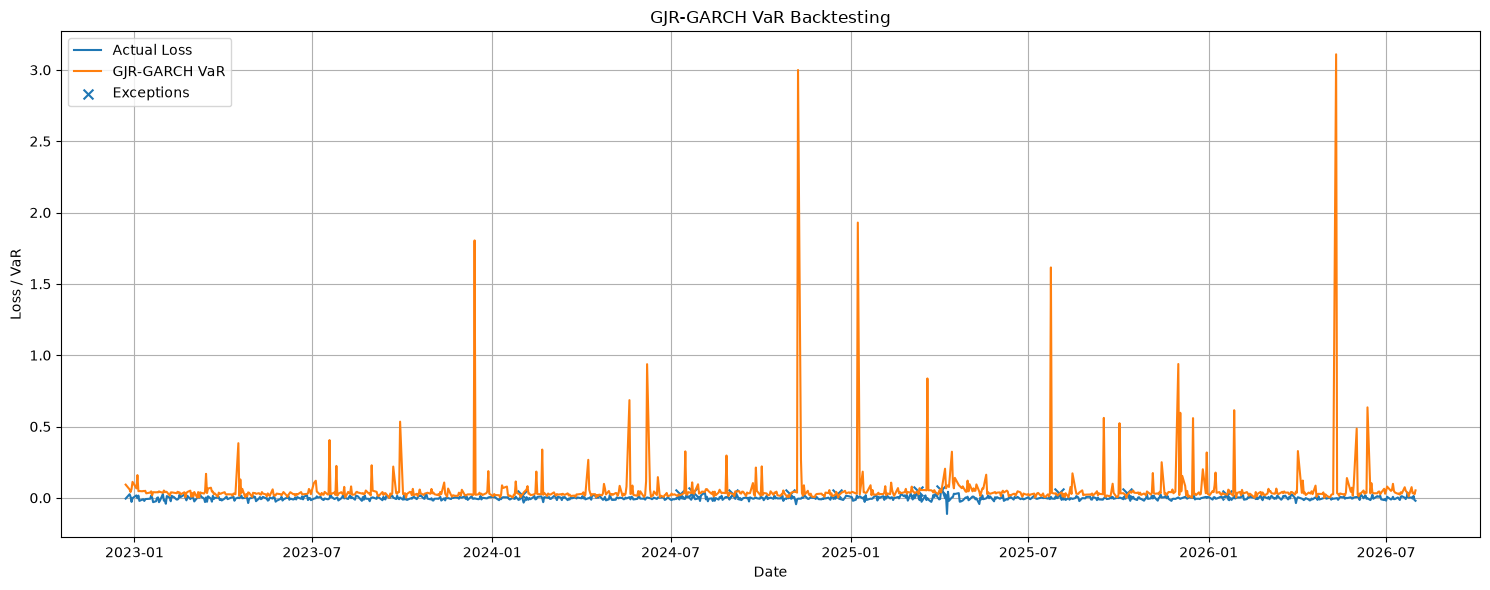

In [179]:
plt.figure(figsize=(15, 6))

plt.plot(
    backtest_complete_df["Date"],
    backtest_complete_df["Actual Loss"],
    label="Actual Loss"
)

plt.plot(
    backtest_complete_df["Date"],
    backtest_complete_df["GJR-GARCH VaR"],
    label="GJR-GARCH VaR"
)

exceptions = (
    backtest_complete_df["Actual Loss"]
    >
    backtest_complete_df["GJR-GARCH VaR"]
)

plt.scatter(
    backtest_complete_df.loc[
        exceptions,
        "Date"
    ],
    backtest_complete_df.loc[
        exceptions,
        "Actual Loss"
    ],
    marker="x",
    s=50,
    label="Exceptions"
)

plt.title(
    "GJR-GARCH VaR Backtesting"
)

plt.xlabel("Date")
plt.ylabel("Loss / VaR")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [180]:
backtest_observations_path = (
    RISK_PATH
    / "backtest_observations.csv"
)

backtest_complete_df.to_csv(
    backtest_observations_path,
    index=False
)

print(
    "Saved detailed observations:"
)

print(
    backtest_observations_path
)

Saved detailed observations:
C:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk\data\risk\backtest_observations.csv


In [181]:
backtest_results_path = (
    RISK_PATH
    / "backtest_results.csv"
)

results_df.to_csv(
    backtest_results_path,
    index=False
)

print(
    "Saved final results:"
)

print(
    backtest_results_path
)

Saved final results:
C:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk\data\risk\backtest_results.csv


In [182]:
print("=" * 90)
print("PHASE 8 — VaR BACKTESTING REPORT")
print("=" * 90)

print(
    f"Confidence Level : {CONFIDENCE_LEVEL:.0%}"
)

print(
    f"Estimation Window: {ESTIMATION_WINDOW} days"
)

print(
    f"OOS Observations : "
    f"{len(backtest_complete_df)}"
)

print("=" * 90)

for _, row in results_df.iterrows():

    print(
        f"\nMODEL: {row['Model']}"
    )

    print(
        f"Observations: "
        f"{row['Observations']}"
    )

    print(
        f"Exceptions: "
        f"{row['Exceptions']}"
    )

    print(
        f"Expected Exceptions: "
        f"{row['Expected Exceptions']:.2f}"
    )

    print(
        f"Exception Ratio: "
        f"{row['Exception Ratio']:.2%}"
    )

    print(
        f"Kupiec POF: "
        f"{'PASS' if row['Kupiec Pass'] else 'FAIL'}"
    )

    print(
        f"Kupiec p-value: "
        f"{row['Kupiec p-value']:.4f}"
    )

    print(
        f"Christoffersen Independence: "
        f"{'PASS' if row['Independence Pass'] else 'FAIL'}"
    )

    print(
        f"Independence p-value: "
        f"{row['Independence p-value']:.4f}"
    )

    print(
        f"Conditional Coverage: "
        f"{'PASS' if row['Conditional Coverage Pass'] else 'FAIL'}"
    )

    print(
        f"Conditional Coverage p-value: "
        f"{row['Conditional Coverage p-value']:.4f}"
    )

    print(
        f"Basel Traffic Light: "
        f"{row['Basel Zone']}"
    )

print("\n" + "=" * 90)
print("PHASE 8 COMPLETE")
print("=" * 90)

PHASE 8 — VaR BACKTESTING REPORT
Confidence Level : 99%
Estimation Window: 750 days
OOS Observations : 902

MODEL: Historical
Observations: 902
Exceptions: 31
Expected Exceptions: 9.02
Exception Ratio: 3.44%
Kupiec POF: FAIL
Kupiec p-value: 0.0000
Christoffersen Independence: FAIL
Independence p-value: 0.0212
Conditional Coverage: FAIL
Conditional Coverage p-value: 0.0000
Basel Traffic Light: N/A

MODEL: EWMA
Observations: 902
Exceptions: 44
Expected Exceptions: 9.02
Exception Ratio: 4.88%
Kupiec POF: FAIL
Kupiec p-value: 0.0000
Christoffersen Independence: PASS
Independence p-value: 0.2303
Conditional Coverage: FAIL
Conditional Coverage p-value: 0.0000
Basel Traffic Light: N/A

MODEL: GARCH
Observations: 902
Exceptions: 11
Expected Exceptions: 9.02
Exception Ratio: 1.22%
Kupiec POF: PASS
Kupiec p-value: 0.5218
Christoffersen Independence: PASS
Independence p-value: 0.6020
Conditional Coverage: PASS
Conditional Coverage p-value: 0.7110
Basel Traffic Light: N/A

MODEL: GJR-GARCH
Observa